<a href="https://colab.research.google.com/github/ASAbuSayem/Hybrid-Models-for-Parkinson-s-Disease-PD-Detection/blob/main/Model_1_HOG_ML_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model 1: HOG + LBP Feature Extraction → ML Classifiers
## Parkinson's Disease Detection — Baseline ML Approach
**Book Chapter 14:** Healthcare and Biomedical Applications | AI Hybrid Neural Networks (Scrivener/Wiley)

---
### Pipeline
```
Spiral/Wave Images → Preprocessing → HOG + LBP Features → SVM / RF / XGBoost → Evaluation
```
- **Dataset:** PD Spiral & Wave Drawings (Healthy vs Parkinson)
- **Features:** Histogram of Oriented Gradients (HOG) + Local Binary Pattern (LBP)
- **Classifiers:** SVM, Random Forest, XGBoost, KNN, Logistic Regression
- **Goal:** Lightweight baseline — fast inference, no GPU needed

In [ ]:
# STEP 1: Install & Import
!pip install xgboost scikit-image imbalanced-learn -q

import os, zipfile, cv2, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from skimage.feature import hog, local_binary_pattern
from skimage import exposure
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc, f1_score)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import joblib, time

print('All libraries loaded successfully!')

All libraries loaded successfully!


In [ ]:
# STEP 2: Upload & Extract Dataset
from google.colab import files

print('Upload your PD-Dataset.zip file...')
uploaded = files.upload()   # Upload PD-Dataset.zip

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/')
print('Dataset extracted!')

# Auto-detect dataset root
DATASET_ROOT = '/content/PD-Dataset'
print(f'\n Dataset structure:')
for root, dirs, files_ in os.walk(DATASET_ROOT):
    level = root.replace(DATASET_ROOT, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent} {os.path.basename(root)}/ ({len(files_)} files)')

Upload your PD-Dataset.zip file...


Saving PD-Dataset.zip to PD-Dataset.zip
Dataset extracted!

 Dataset structure:
 PD-Dataset/ (0 files)
   drawings/ (0 files)
     spiral/ (0 files)
       training/ (0 files)
         healthy/ (36 files)
         parkinson/ (36 files)
       testing/ (0 files)
         healthy/ (15 files)
         parkinson/ (15 files)
     wave/ (0 files)
       training/ (0 files)
         healthy/ (36 files)
         parkinson/ (36 files)
       testing/ (0 files)
         healthy/ (15 files)
         parkinson/ (15 files)
   spiral/ (0 files)
     training/ (0 files)
       healthy/ (36 files)
       parkinson/ (36 files)
     testing/ (0 files)
       healthy/ (15 files)
       parkinson/ (15 files)
   wave/ (0 files)
     training/ (0 files)
       healthy/ (36 files)
       parkinson/ (36 files)
     testing/ (0 files)
       healthy/ (15 files)
       parkinson/ (15 files)


In [ ]:
# STEP 3: Configuration
IMG_SIZE    = (128, 128)
DRAWING_TYPES = ['spiral', 'wave']
CLASSES    = ['healthy', 'parkinson']

# HOG parameters
HOG_PARAMS = {
    'orientations': 9,
    'pixels_per_cell': (8, 8),
    'cells_per_block': (2, 2),
    'visualize': False,
    'feature_vector': True
}

# LBP parameters
LBP_RADIUS  = 3
LBP_POINTS  = 8 * LBP_RADIUS
LBP_METHOD  = 'uniform'

RANDOM_STATE = 42
print(' Configuration set!')
print(f'   Image size: {IMG_SIZE}')
print(f'   HOG orientations: {HOG_PARAMS["orientations"]}')
print(f'   LBP points: {LBP_POINTS}, radius: {LBP_RADIUS}')

 Configuration set!
   Image size: (128, 128)
   HOG orientations: 9
   LBP points: 24, radius: 3


In [ ]:
# STEP 4: Feature Extraction Functions

def preprocess_image(img_path, size=IMG_SIZE):
    """Load, resize, and convert to grayscale."""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, size)
    # Enhance contrast using CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    return img

def extract_hog_features(img):
    """Extract HOG features from grayscale image."""
    features = hog(img, **HOG_PARAMS)
    return features

def extract_lbp_features(img, num_bins=26):
    """Extract LBP histogram features from grayscale image."""
    lbp = local_binary_pattern(img, LBP_POINTS, LBP_RADIUS, method=LBP_METHOD)
    hist, _ = np.histogram(lbp.ravel(),
                           bins=np.arange(0, LBP_POINTS + 3),
                           range=(0, LBP_POINTS + 2))
    hist = hist.astype('float')
    hist /= (hist.sum() + 1e-6)  # Normalize
    return hist

def extract_geometric_features(img):
    """Extract geometric / statistical texture features."""
    feats = [
        np.mean(img),
        np.std(img),
        np.var(img),
        np.percentile(img, 25),
        np.percentile(img, 75),
        np.max(img) - np.min(img),   # Dynamic range
        np.sum(img > 127) / img.size  # White pixel ratio
    ]
    return np.array(feats)

def extract_all_features(img_path):
    """Full feature pipeline: HOG + LBP + Geometric → concatenated vector."""
    img = preprocess_image(img_path)
    hog_feat  = extract_hog_features(img)       # ~1764 dims
    lbp_feat  = extract_lbp_features(img)       # 26 dims
    geo_feat  = extract_geometric_features(img) # 7 dims
    return np.concatenate([hog_feat, lbp_feat, geo_feat])

print(' Feature extraction functions defined!')
print(f'   HOG feature length  : ~1764')
print(f'   LBP feature length  : {LBP_POINTS + 2}')
print(f'   Geometric features  : 7')

 Feature extraction functions defined!
   HOG feature length  : ~1764
   LBP feature length  : 26
   Geometric features  : 7


In [ ]:
# STEP 5: Load Dataset & Extract Features

def load_dataset(drawing_type='spiral'):
    """Load images and extract features for a given drawing type."""
    X_train, y_train, X_test, y_test = [], [], [], []
    base = os.path.join(DATASET_ROOT, drawing_type)

    for split, X_list, y_list in [('training', X_train, y_train),
                                   ('testing',  X_test,  y_test)]:
        for label in CLASSES:
            folder = os.path.join(base, split, label)
            for fname in os.listdir(folder):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    path = os.path.join(folder, fname)
                    feat = extract_all_features(path)
                    X_list.append(feat)
                    y_list.append(0 if label == 'healthy' else 1)

    return (np.array(X_train), np.array(y_train),
            np.array(X_test),  np.array(y_test))

# Extract for both drawing types and combine
print('Extracting features from Spiral images...')
t0 = time.time()
Xtr_s, ytr_s, Xte_s, yte_s = load_dataset('spiral')
print(f'   Spiral done in {time.time()-t0:.1f}s | Train: {Xtr_s.shape}, Test: {Xte_s.shape}')

print('Extracting features from Wave images...')
t0 = time.time()
Xtr_w, ytr_w, Xte_w, yte_w = load_dataset('wave')
print(f'   Wave done in {time.time()-t0:.1f}s | Train: {Xtr_w.shape}, Test: {Xte_w.shape}')

# Combine both drawing types
X_train = np.concatenate([Xtr_s, Xtr_w], axis=0)
y_train = np.concatenate([ytr_s, ytr_w], axis=0)
X_test  = np.concatenate([Xte_s, Xte_w], axis=0)
y_test  = np.concatenate([yte_s, yte_w], axis=0)

print(f'\n Combined Dataset:')
print(f'   X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'   X_test : {X_test.shape},  y_test : {y_test.shape}')
print(f'   Feature vector dimension: {X_train.shape[1]}')

Extracting features from Spiral images...
   Spiral done in 2.6s | Train: (72, 8133), Test: (30, 8133)
Extracting features from Wave images...
   Wave done in 3.3s | Train: (72, 8133), Test: (30, 8133)

 Combined Dataset:
   X_train: (144, 8133), y_train: (144,)
   X_test : (60, 8133),  y_test : (60,)
   Feature vector dimension: 8133


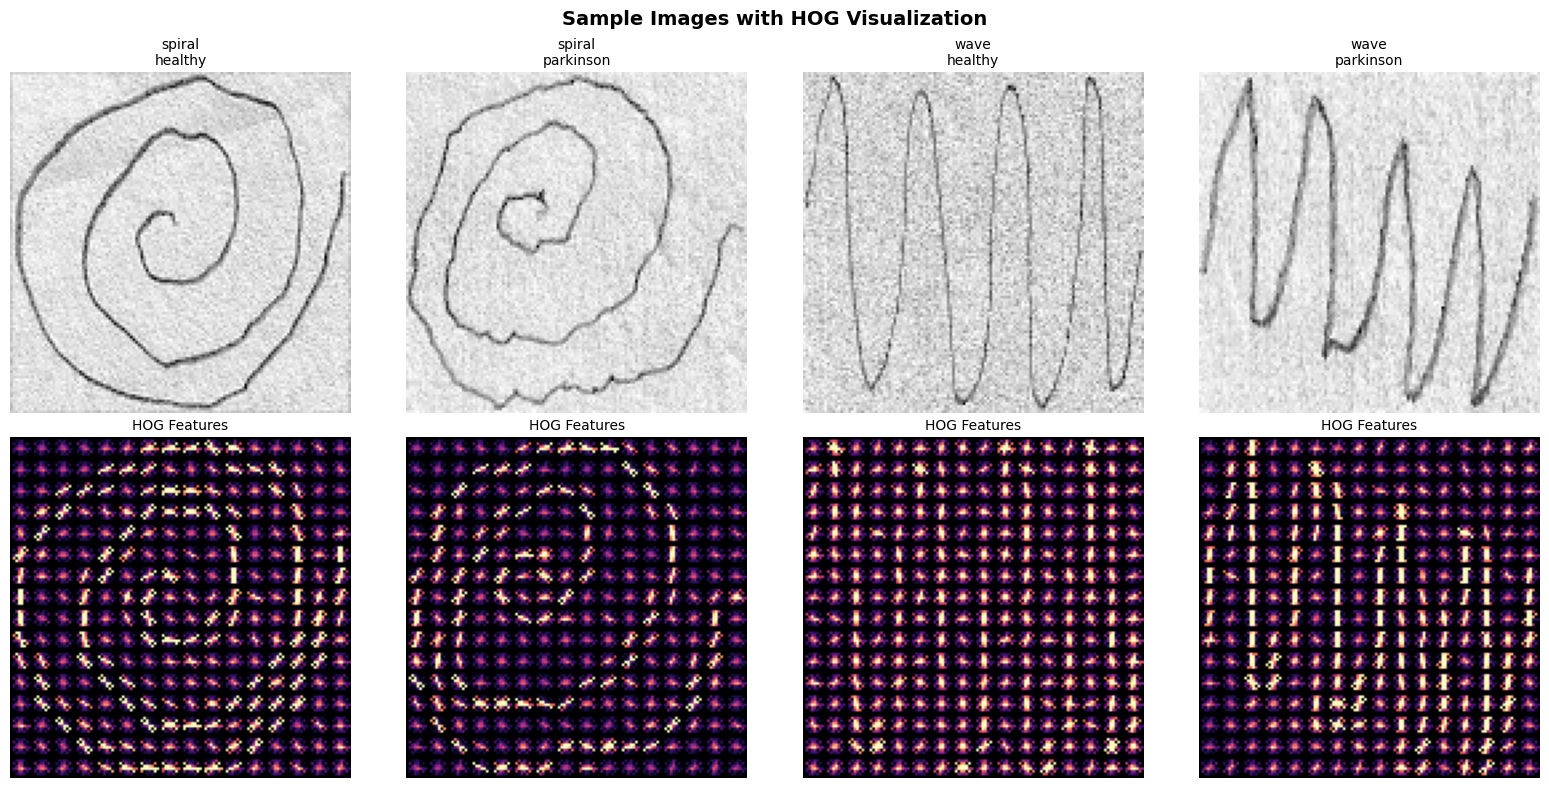

 HOG visualization saved.


In [ ]:
# STEP 6: Visualize Sample Images + HOG
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Images with HOG Visualization', fontsize=14, fontweight='bold')

sample_paths = []
for dtype in ['spiral', 'wave']:
    for label in ['healthy', 'parkinson']:
        folder = os.path.join(DATASET_ROOT, dtype, 'training', label)
        fname = os.listdir(folder)[0]
        sample_paths.append((os.path.join(folder, fname), f'{dtype}\n{label}'))

for i, (path, title) in enumerate(sample_paths):
    img = preprocess_image(path)
    hog_feat, hog_img = hog(img, **{**HOG_PARAMS, 'visualize': True})
    hog_img = exposure.rescale_intensity(hog_img, in_range=(0, 10))

    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(title, fontsize=10)
    axes[0, i].axis('off')

    axes[1, i].imshow(hog_img, cmap='magma')
    axes[1, i].set_title('HOG Features', fontsize=10)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('HOG', fontsize=11)
plt.tight_layout()
plt.savefig('/content/M1_HOG_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(' HOG visualization saved.')

In [ ]:
# STEP 7: Feature Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f' Features scaled: mean≈0, std≈1')
print(f'   Train mean: {X_train_sc.mean():.4f}, std: {X_train_sc.std():.4f}')

 Features scaled: mean≈0, std≈1
   Train mean: -0.0000, std: 1.0000


In [ ]:
# STEP 8: Train & Evaluate All Classifiers

classifiers = {
    'SVM (RBF)'     : SVC(kernel='rbf', C=10, gamma='scale',
                          probability=True, random_state=RANDOM_STATE),
    'SVM (Linear)'  : SVC(kernel='linear', C=1,
                          probability=True, random_state=RANDOM_STATE),
    'Random Forest' : RandomForestClassifier(n_estimators=200, max_depth=10,
                                             random_state=RANDOM_STATE),
    'XGBoost'       : XGBClassifier(n_estimators=150, learning_rate=0.1,
                                    max_depth=5, use_label_encoder=False,
                                    eval_metric='logloss',
                                    random_state=RANDOM_STATE),
    'KNN (k=5)'     : KNeighborsClassifier(n_neighbors=5),
    'Logistic Reg.' : LogisticRegression(C=1.0, max_iter=1000,
                                         random_state=RANDOM_STATE),
}

results = []
trained_models = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f'{"Model":<20} {"CV Acc":>8} {"Test Acc":>9} {"F1":>8} {"Time(s)":>9}')
print('-' * 60)

for name, clf in classifiers.items():
    t_start = time.time()

    # Cross-validation
    cv_scores = cross_val_score(clf, X_train_sc, y_train, cv=cv, scoring='accuracy')

    # Fit on full training set
    clf.fit(X_train_sc, y_train)
    t_elapsed = time.time() - t_start

    # Test set evaluation
    y_pred = clf.predict(X_test_sc)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    trained_models[name] = clf
    results.append({
        'Model': name,
        'CV Accuracy': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test Accuracy': acc,
        'F1-Score': f1,
        'Time (s)': t_elapsed
    })
    print(f'{name:<20} {cv_scores.mean()*100:7.2f}% {acc*100:8.2f}% {f1*100:7.2f}% {t_elapsed:8.2f}s')

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)
print('\n Training complete!')

Model                  CV Acc  Test Acc       F1   Time(s)
------------------------------------------------------------
SVM (RBF)              77.86%    78.33%   80.00%     2.36s
SVM (Linear)           75.76%    71.67%   74.63%     2.22s
Random Forest          65.96%    68.33%   70.77%     8.72s
XGBoost                63.94%    63.33%   65.62%   145.36s
KNN (k=5)              72.34%    75.00%   71.70%     0.12s
Logistic Reg.          75.79%    71.67%   73.85%     0.99s

 Training complete!


In [ ]:
# STEP 9: Results Table
print('\n Full Results Table:')
display(results_df.style
        .format({'CV Accuracy': '{:.2%}', 'CV Std': '±{:.3f}',
                 'Test Accuracy': '{:.2%}', 'F1-Score': '{:.2%}',
                 'Time (s)': '{:.2f}s'})
        .background_gradient(subset=['Test Accuracy'], cmap='YlGn')
        .highlight_max(subset=['Test Accuracy'], color='lightgreen')
        .set_caption('Model 1 — HOG+LBP ML Classifiers Comparison'))


 Full Results Table:


,Model,CV Accuracy,CV Std,Test Accuracy,F1-Score,Time (s)
0,SVM (RBF),77.86%,±0.070,78.33%,80.00%,2.36s
4,KNN (k=5),72.34%,±0.106,75.00%,71.70%,0.12s
1,SVM (Linear),75.76%,±0.074,71.67%,74.63%,2.22s
5,Logistic Reg.,75.79%,±0.080,71.67%,73.85%,0.99s
2,Random Forest,65.96%,±0.067,68.33%,70.77%,8.72s
3,XGBoost,63.94%,±0.097,63.33%,65.62%,145.36s


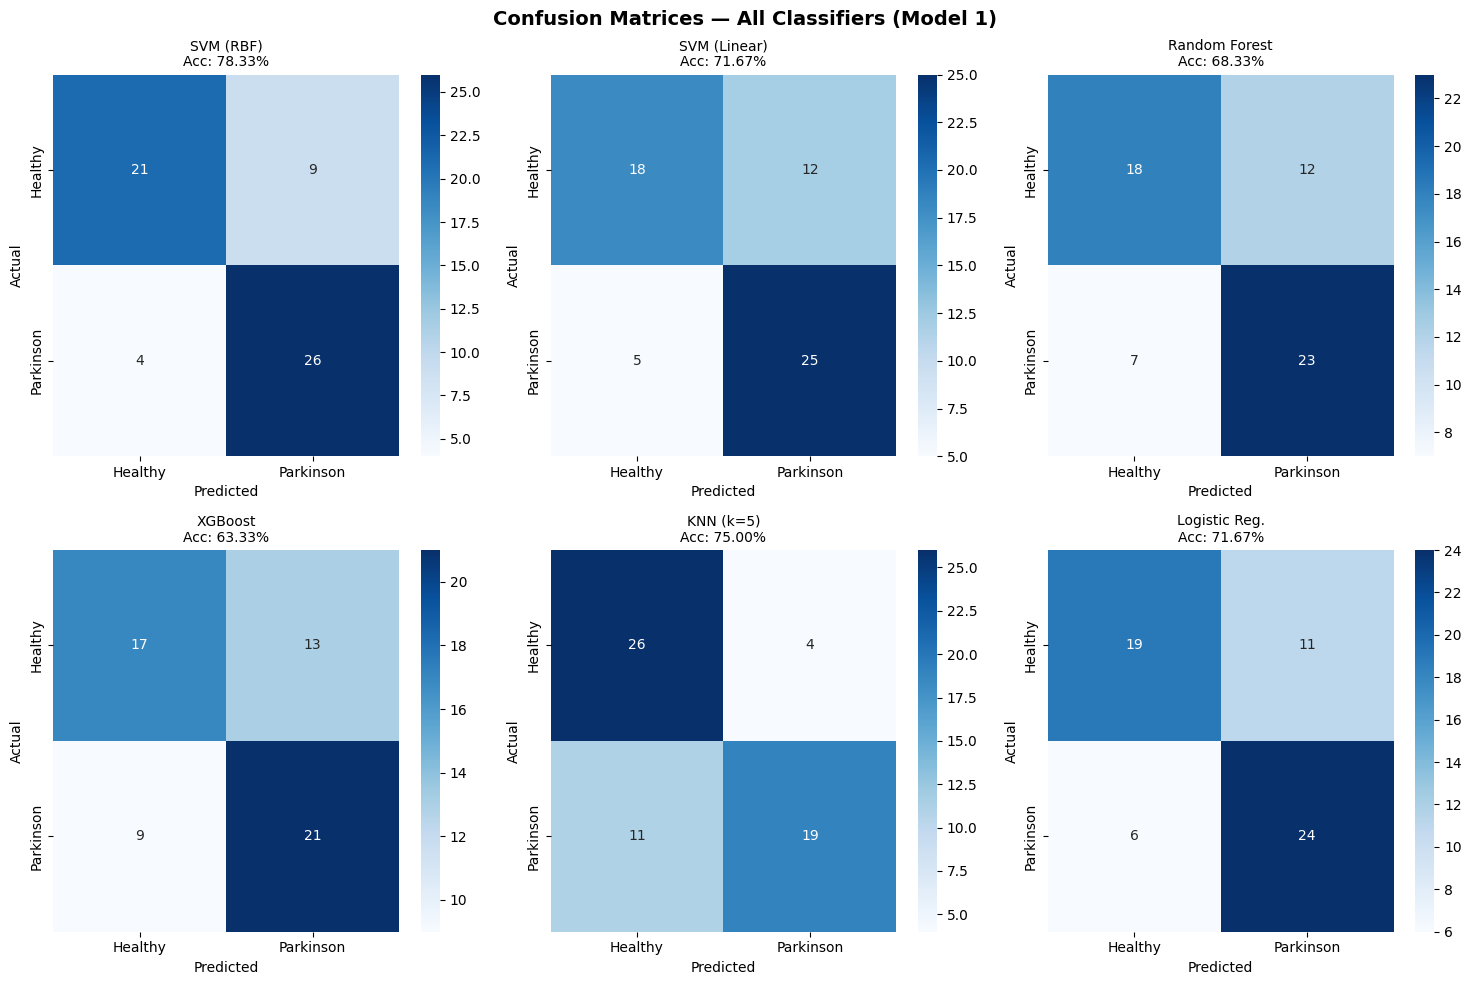

Confusion matrices saved.


In [ ]:
# STEP 10: Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Confusion Matrices — All Classifiers (Model 1)', fontsize=14, fontweight='bold')

for ax, (name, clf) in zip(axes.flatten(), trained_models.items()):
    y_pred = clf.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Healthy', 'Parkinson'],
                yticklabels=['Healthy', 'Parkinson'])
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}\nAcc: {acc:.2%}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('/content/M1_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrices saved.')

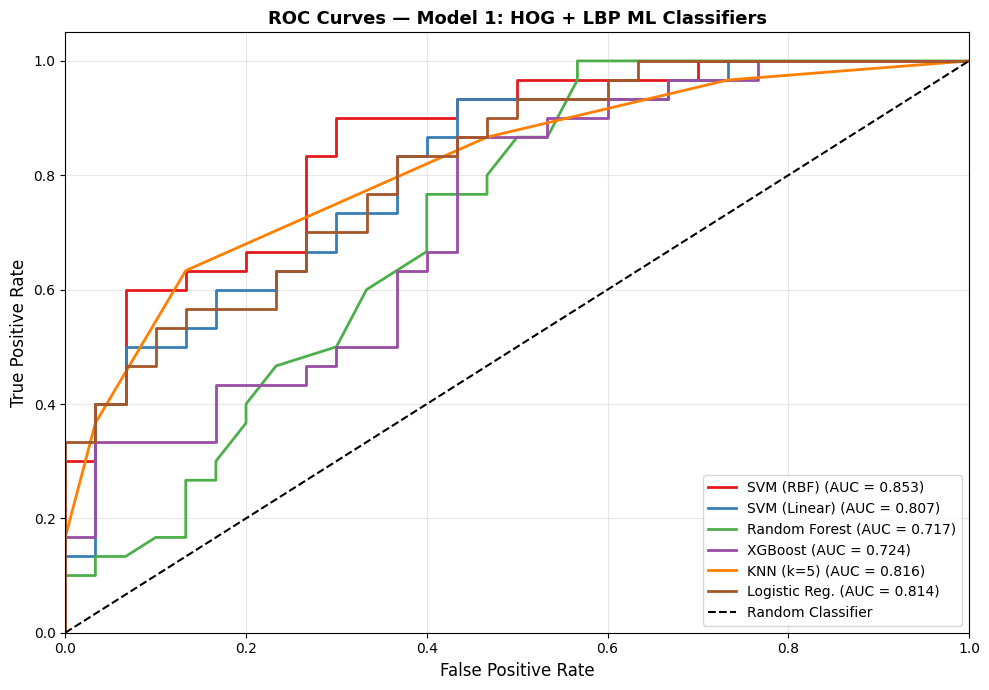

ROC curves saved.


In [ ]:
# STEP 11: ROC Curves
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628']
for (name, clf), color in zip(trained_models.items(), colors):
    if hasattr(clf, 'predict_proba'):
        y_prob = clf.predict_proba(X_test_sc)[:, 1]
    else:
        y_prob = clf.decision_function(X_test_sc)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1],'k--', lw=1.5, label='Random Classifier')
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Model 1: HOG + LBP ML Classifiers', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/M1_ROC_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('ROC curves saved.')

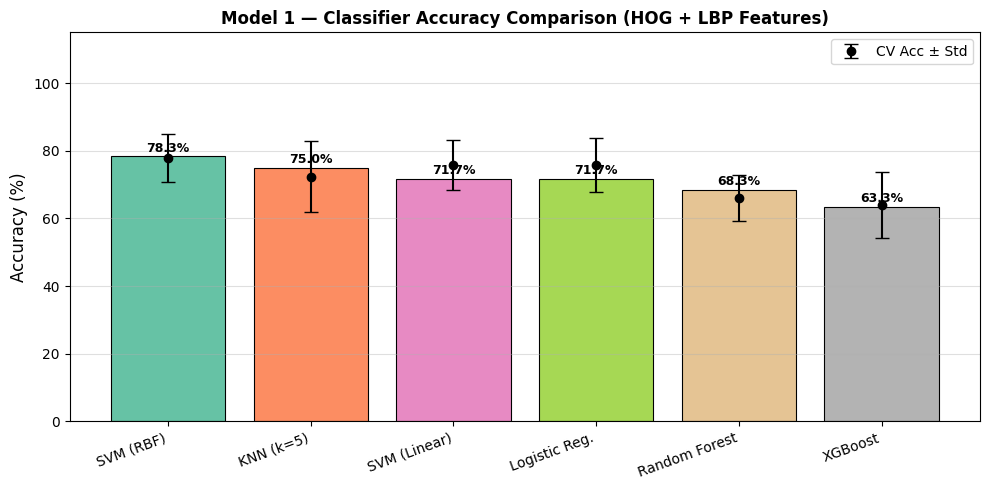

In [ ]:
# STEP 12: Accuracy Comparison Bar Chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
bars = ax.bar(x, results_df['Test Accuracy'] * 100,
              color=plt.cm.Set2(np.linspace(0, 1, len(results_df))),
              edgecolor='black', linewidth=0.8)
ax.errorbar(x, results_df['CV Accuracy'] * 100,
            yerr=results_df['CV Std'] * 100,
            fmt='o', color='black', capsize=5, label='CV Acc ± Std')

for bar, val in zip(bars, results_df['Test Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model 1 — Classifier Accuracy Comparison (HOG + LBP Features)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('/content/M1_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# STEP 13: Best Model Classification Report
best_name = results_df.iloc[0]['Model']
best_clf  = trained_models[best_name]
y_pred    = best_clf.predict(X_test_sc)

print(f' Best Model: {best_name}')
print(f'   Test Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'   F1-Score      : {f1_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred,
                             target_names=['Healthy', 'Parkinson']))

 Best Model: SVM (RBF)
   Test Accuracy : 0.7833
   F1-Score      : 0.8000

              precision    recall  f1-score   support

     Healthy       0.84      0.70      0.76        30
   Parkinson       0.74      0.87      0.80        30

    accuracy                           0.78        60
   macro avg       0.79      0.78      0.78        60
weighted avg       0.79      0.78      0.78        60



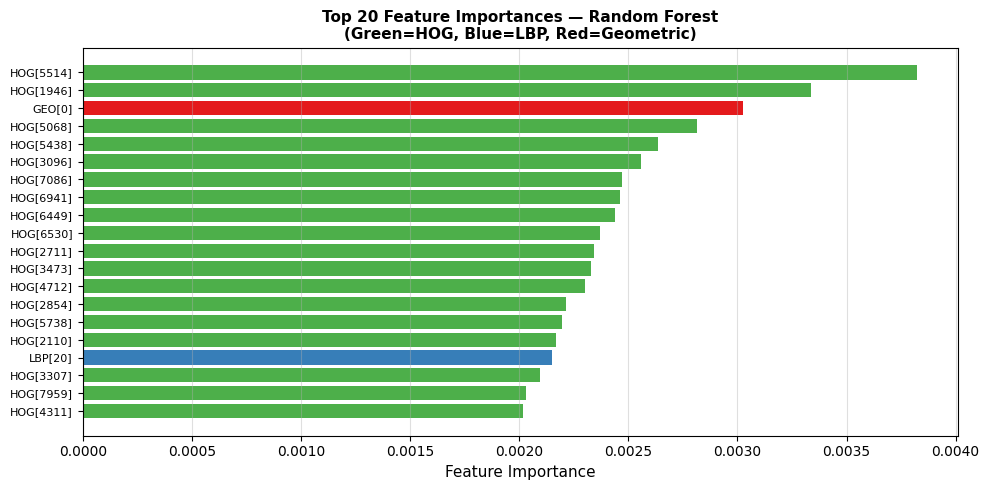

Feature importance plot saved.


In [ ]:
# STEP 14: Feature Importance (Random Forest)
rf_model = trained_models['Random Forest']
importances = rf_model.feature_importances_
top_n = 20
top_idx = np.argsort(importances)[-top_n:][::-1]

# Label feature types
hog_len = len(extract_hog_features(preprocess_image(
    os.path.join(DATASET_ROOT, 'spiral', 'training', 'healthy',
                 os.listdir(os.path.join(DATASET_ROOT,'spiral','training','healthy'))[0]))))
lbp_len = LBP_POINTS + 2

def feat_name(idx):
    if idx < hog_len: return f'HOG[{idx}]'
    elif idx < hog_len + lbp_len: return f'LBP[{idx-hog_len}]'
    else: return f'GEO[{idx-hog_len-lbp_len}]'

feat_labels = [feat_name(i) for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(top_n), importances[top_idx][::-1],
        color=['#4daf4a' if 'HOG' in f else '#377eb8' if 'LBP' in f else '#e41a1c'
               for f in feat_labels[::-1]])
ax.set_yticks(range(top_n))
ax.set_yticklabels(feat_labels[::-1], fontsize=8)
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title(f'Top {top_n} Feature Importances — Random Forest\n(Green=HOG, Blue=LBP, Red=Geometric)',
             fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('/content/M1_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance plot saved.')

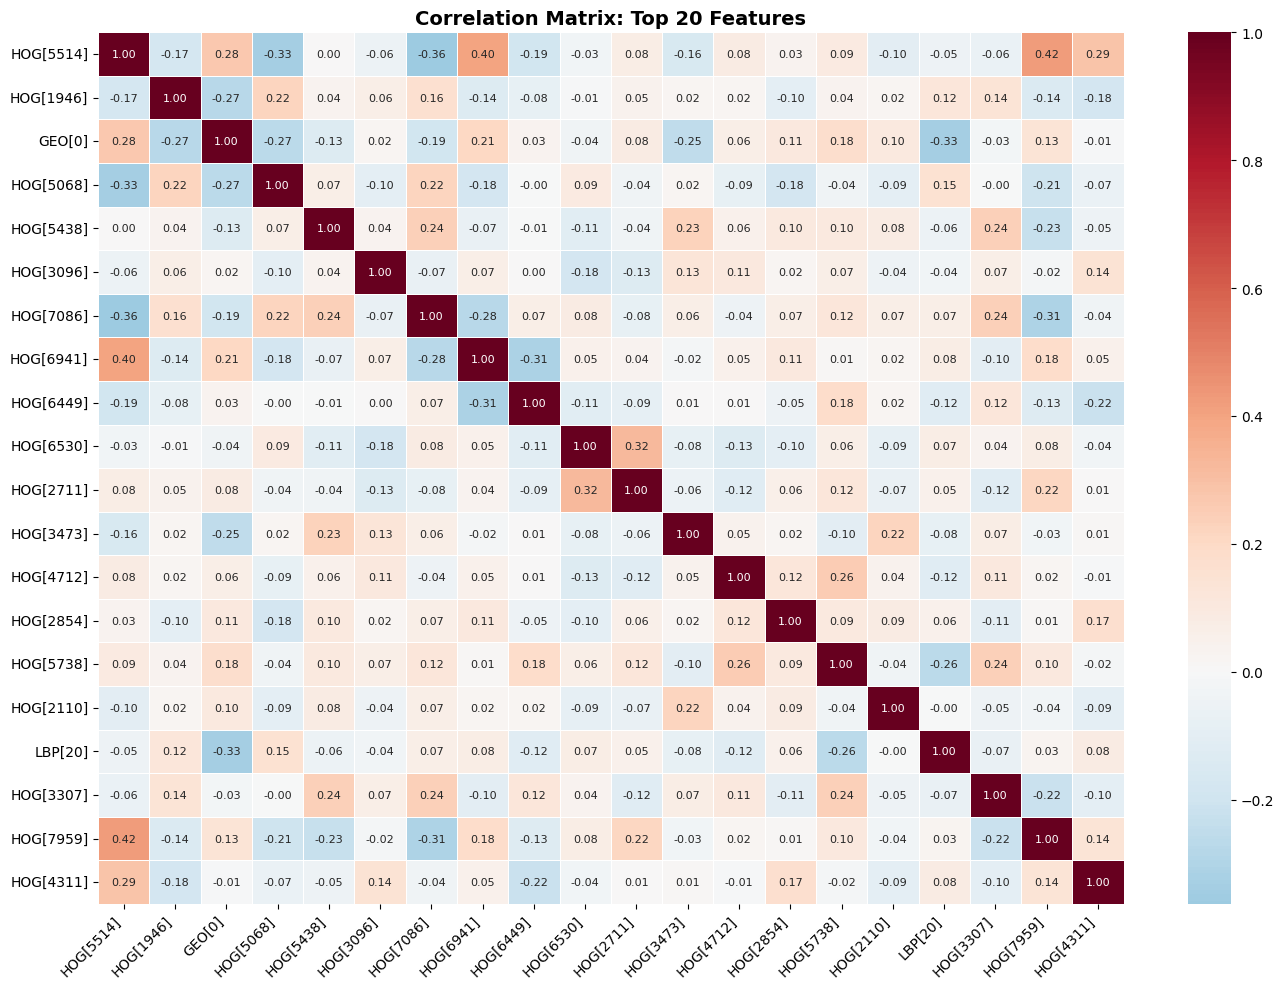

Correlation matrix for top features plotted and saved.


In [ ]:
# STEP 15: Correlation Matrix for Top Features
import seaborn as sns

# Get top 20 feature indices from previous RF importance
top_n = 20
top_idx = np.argsort(importances)[-top_n:][::-1]

# Create a DataFrame for these features using scaled training data
top_feat_names = [feat_name(i) for i in top_idx]
df_top_feats = pd.DataFrame(X_train_sc[:, top_idx], columns=top_feat_names)

# Calculate correlation matrix
corr_matrix = df_top_feats.corr()

# Plot Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            linewidths=0.5, annot_kws={'size': 8})

plt.title(f'Correlation Matrix: Top {top_n} Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/M1_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation matrix for top features plotted and saved.')

In [ ]:
# STEP 16: Save Best Model
joblib.dump(best_clf, '/content/M1_best_model.pkl')
joblib.dump(scaler,   '/content/M1_scaler.pkl')
results_df.to_csv('/content/M1_results.csv', index=False)

print(' Model 1 Artifacts Saved:')
print('   /content/M1_best_model.pkl')
print('   /content/M1_scaler.pkl')
print('   /content/M1_results.csv')
print('   /content/M1_HOG_visualization.png')
print('   /content/M1_confusion_matrices.png')
print('   /content/M1_ROC_curves.png')
print('   /content/M1_accuracy_comparison.png')
print('   /content/M1_feature_importance.png')
print()
print('='*60)
print('MODEL 1 SUMMARY — HOG + LBP → ML Classifiers')
print('='*60)
print(f'  Feature Vector Size : {X_train.shape[1]} dimensions')
print(f'  Best Classifier     : {best_name}')
print(f'  Best Test Accuracy  : {results_df.iloc[0]["Test Accuracy"]:.2%}')
print(f'  Best F1-Score       : {results_df.iloc[0]["F1-Score"]:.2%}')
print(f'  Training Speed      : Very Fast (no GPU needed)')
print(f'  Model Size          : < 5 MB')
print('='*60)

 Model 1 Artifacts Saved:
   /content/M1_best_model.pkl
   /content/M1_scaler.pkl
   /content/M1_results.csv
   /content/M1_HOG_visualization.png
   /content/M1_confusion_matrices.png
   /content/M1_ROC_curves.png
   /content/M1_accuracy_comparison.png
   /content/M1_feature_importance.png

MODEL 1 SUMMARY — HOG + LBP → ML Classifiers
  Feature Vector Size : 8133 dimensions
  Best Classifier     : SVM (RBF)
  Best Test Accuracy  : 78.33%
  Best F1-Score       : 80.00%
  Training Speed      : Very Fast (no GPU needed)
  Model Size          : < 5 MB
